# myBCA App Reviews - Data Collection (5,000 Reviews)
**Project:** Sentiment Analysis of myBCA Mobile Banking App Reviews   
**Author:** Elvia Aptanisa  
**Purpose:** Collect full dataset (5,000 reviews) for sentiment analysis.

---

## Step 1 - Install Library

In [34]:
!pip install google-play-scraper

## Step 2 - Import Library


In [35]:
from google_play_scraper import reviews, Sort

import pandas as pd

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 3 - Scraping Review myBCA


In [36]:
from google_play_scraper import app

try:
    app_info = app('com.bca.mybca.omni.android', lang='id', country='id')
    print(f"Nama      : {app_info['title']}")
    print(f"Developer : {app_info['developer']}")
    print(f"Rating    : {app_info['score']}")
except Exception as e:
    print(f"Error: {e}")

Nama      : myBCA: BCA Banking Apps
Developer : PT Bank Central Asia Tbk.
Rating    : 3.7791955


In [37]:
from google_play_scraper import reviews, Sort
import time

print("Scraping reviews myBCA...")

result, _ = reviews(
    'com.bca.mybca.omni.android',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=5000
)

time.sleep(2)
print(f"Success scrape {len(result)} reviews!")

Scraping reviews myBCA...
Success scrape 5000 reviews!


## Step 4 - View Raw Data Structure


In [38]:
print("Example 1 review:")
print("="*50)
sample = result[0]
print(f"Username  : {sample['userName']}")
print(f"Review    : {sample['content']}")
print(f"Rating    : {sample['score']} star")
print(f"Date   : {sample['at']}")
print("="*50)

Example 1 review:
Username  : Pengguna Google
Review    : ribet vermuk buat orang mata minus 5 lepas kacamata susah baca panduan nya gagal suruh vidio call udah 3 hari ini kemaren kehalangan otp sekarang udah tinggal verif malah suruh vidio cal
Rating    : 2 star
Date   : 2026-05-16 18:29:39


## Step 5 - Create DataFrame & Choose Columns to Use


In [39]:
df = pd.DataFrame(result)[['content', 'score']]
df.columns = ['review', 'rating']

print(f"DataFrame created with {len(df)} rows and {len(df.columns)} columns")
print(f"Columns: {list(df.columns)}")

DataFrame created with 5000 rows and 2 columns
Columns: ['review', 'rating']


## Step 6 - Add Auto Sentiment Labels


In [40]:
def label_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['rating'].apply(label_sentiment)

print("Sentiment labels added!")
print("\n Label distribution:")
print(df['sentiment'].value_counts())

Sentiment labels added!

 Label distribution:
sentiment
Negative    2453
Positive    2103
Neutral      444
Name: count, dtype: int64


## Step 7 - Preview Dataset

Lihat 10 baris pertama dataset kita yang sudah rapi.

In [41]:
print("Preview dataset (First 10 rows):")
df.head(10)

Preview dataset (First 10 rows):


,review,rating,sentiment
0,ribet vermuk buat orang mata minus 5 lepas kac...,2,Negative
1,buka ebanking lemot banget,2,Negative
2,bagus,5,Positive
3,ok,5,Positive
4,ko skrg gak ad notifikasi uang masuk y dari ak...,5,Positive
5,asik,5,Positive
6,BCA ID ku keblokir terus ke apa sih! dari Janu...,1,Negative
7,"fenomena aneh, verifikasi no telepon tidak ada...",2,Negative
8,di perbarui bukannya lebih baik malah jadi gan...,1,Negative
9,sangat di rekomendasikan,5,Positive


## Step 8 - Save Data to CSV File


In [42]:
df.to_csv('mybca_reviews.csv', index=False, encoding='utf-8-sig')

print("Dataset saved as 'mybca_preview.csv'")
print(f"Total reviews: {len(df)}")
print(f"Columns: {list(df.columns)}")
print("\nFinal label distribution:")
print(df['sentiment'].value_counts())

Dataset saved as 'mybca_preview.csv'
Total reviews: 5000
Columns: ['review', 'rating', 'sentiment']

Final label distribution:
sentiment
Negative    2453
Positive    2103
Neutral      444
Name: count, dtype: int64


## Step 9 - Visualisasi Distribusi Label


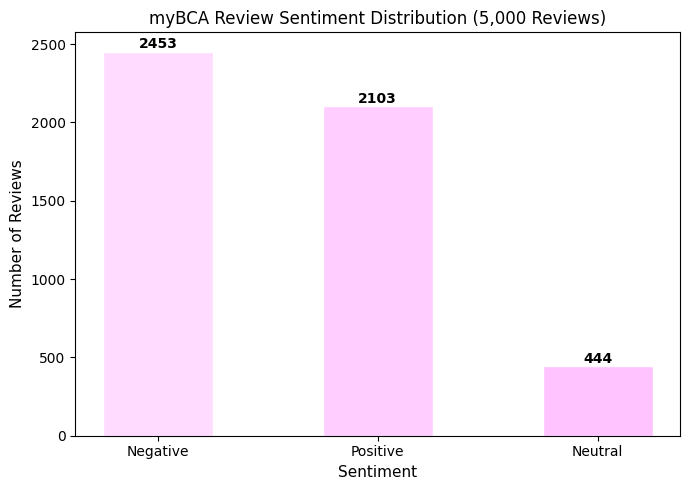

In [43]:
import matplotlib.pyplot as plt

label_counts = df['sentiment'].value_counts()

colors = ['#ffdcff', '#ffcdff', '#ffc3ff']
plt.figure(figsize=(7, 5))
bars = plt.bar(label_counts.index, label_counts.values, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('myBCA Review Sentiment Distribution (5,000 Reviews)')
plt.xlabel('Sentiment', fontsize=11)
plt.ylabel('Number of Reviews', fontsize=11)
plt.tight_layout()
plt.savefig('sentiment_distribution_preview.png', dpi=150)
plt.show()